<a href="https://colab.research.google.com/github/grullaandrea-png/mushroom_classification_model_dervishi/blob/main/AlexNet_5%2C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/dataset_locale/
!unzip -q "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset_locale/"

import os
print(os.listdir("/content/dataset_locale/"))

['Data']


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

data_dir = "/content/dataset_locale/Data"

# 1. Define the trasformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_dataset = datasets.ImageFolder(root=data_dir)


# Divide in 70% Train, 10% Validation and 20% Test
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
test_size = int(0.20 * total_size)
val_size = total_size - train_size - test_size

train_raw, test_raw, val_raw = random_split(full_dataset, [train_size, test_size, val_size])

# Class for the application of the trsformations
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# transformation application
train_dataset = ApplyTransform(train_raw, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_raw, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_raw, transform=data_transforms['val'])

# Create the final dataLoader
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training imagines: {len(train_dataset)}")
print(f"Validation imagines: {len(val_dataset)}")
print(f"Test imagines: {len(test_dataset)}")

Training imagines: 8400
Validation imagines: 1200
Test imagines: 2400


In [5]:
import torch
from torch import nn

net = nn.Sequential(
    # 1. Conv
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 2. Conv
    nn.Conv2d(96, 256, kernel_size=5, padding=2),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 3, 4, 5 Conv
    nn.Conv2d(256, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 12)
)

In [1]:
# Install the d2l library
!pip install -q d2l==1.0.a1.post0
from d2l import torch as d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.3 MB/s eta 0:00:00


In [6]:
import torch
from d2l import torch as d2l

def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, torch.nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device

    metric = d2l.Accumulator(2)

    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())

    return metric[0] / metric[1]

print("Function 'evaluate_accuracy_gpu' correctly upload")

def train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu()):
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print('Training su:', device)
    net.to(device)

    # Optimizer AdamW and scheduler
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    loss = nn.CrossEntropyLoss(label_smoothing=0.1)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'val acc'])

    timer, num_batches = d2l.Timer(), len(train_loader)

    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)
        net.train()

        for i, (X, y) in enumerate(train_loader):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)

            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()

            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

            optimizer.step()

            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()

            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]

            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (train_l, train_acc, None))

        val_acc = evaluate_accuracy_gpu(net, val_loader)
        animator.add(epoch + 1, (None, None, val_acc))

        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}: Loss {train_l:.3f}, Train Acc {train_acc:.3f}, Val Acc {val_acc:.3f}, LR {current_lr:.6f}')

Function 'evaluate_accuracy_gpu' correctly upload


Epoch 50: Loss 0.948, Train Acc 0.855, Val Acc 0.776, LR 0.000000


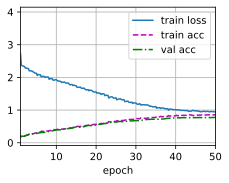

In [7]:
# 1. Define the parameters
lr, num_epochs = 0.0002, 50

# Training function begin
train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu())

In [ ]:
save_path = '/content/drive/MyDrive/Deep_learning_project/mushroom_alexnet5.pth'

**Confusion matrix**

>



Prediction computation on the TEST SET...


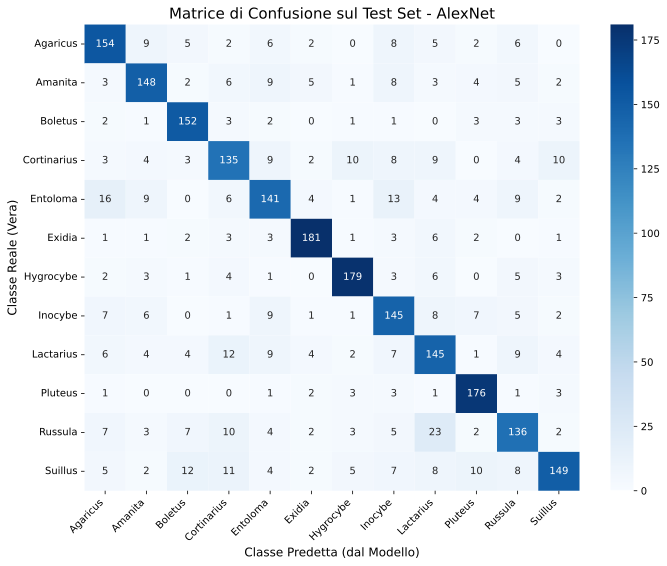

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_scores = []
y_pred = []

print("Prediction computation on the TEST SET...")

net.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(d2l.try_gpu())
        outputs = net(X)

        probs = torch.nn.functional.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_pred = np.array(y_pred)

class_names = full_dataset.classes

# confusion matrix graph
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Classe Predetta (dal Modello)', fontsize=12)
plt.ylabel('Classe Reale (Vera)', fontsize=12)
plt.title('Matrice di Confusione sul Test Set - AlexNet', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**ROC Curve**

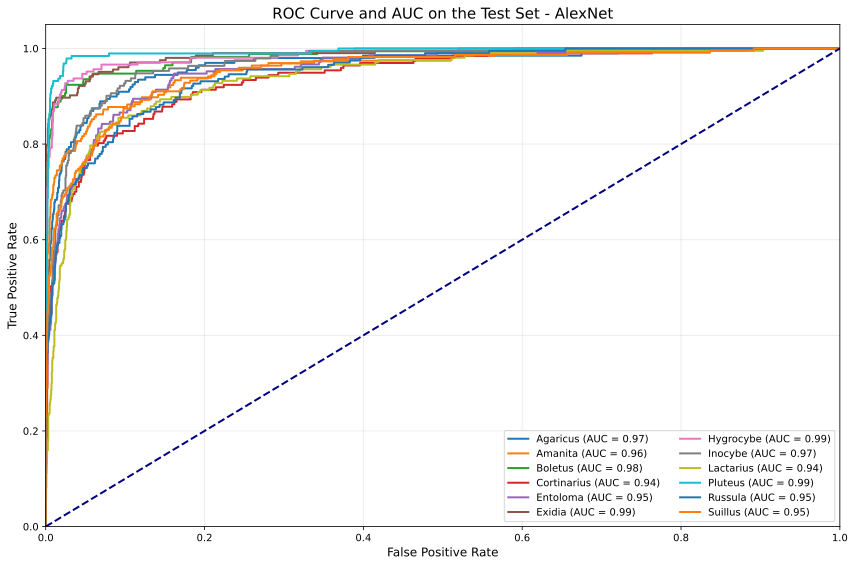

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve and AUC on the Test Set - AlexNet', fontsize=15)
plt.legend(loc="lower right", fontsize=10, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()